# 🚀 Practice Day 15

**📅 Date:** 2026-09-26  
**📁 Category:** Phase 1 · Pandas 기초 (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Explore a single transaction-log table from scratch (거래 로그 테이블을 처음부터 탐색)
- Filter and sort rows based on business conditions (조건에 따라 필터링·정렬)
- Use groupby to calculate basic aggregate metrics (groupby로 기본 집계 계산)
- Same skills as Day 1, new dataset (Day 1과 같은 스킬, 새로운 데이터로 연습)

---
# 📂 Dataset

**Dataset Name:** Convenience Store Daily Transactions (편의점 일별 거래 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 280 individual transactions from a single convenience store over 3 months (Apr-Jun 2026), across 5 categories (Beverages, Snacks, Instant Food, Ice Cream, Household). Includes item, price (USD), quantity, and payment method. Unlike Day 5's multi-store chain, this is one store, one flat table.
(단일 편의점의 3개월치(2026년 4~6월) 거래 280건. 음료/과자/즉석식품/아이스크림/생활용품 5개 카테고리. 상품, 가격(USD), 수량, 결제수단 포함. Day 5의 여러 지점 체인과 달리 이번엔 매장 1곳, 단순한 테이블 1개입니다.)

## Dataset Preview

In [17]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_txn = 280

categories = ['Beverages', 'Snacks', 'Instant Food', 'Ice Cream', 'Household']
category_items = {
    'Beverages': ['Bottled Water', 'Iced Coffee', 'Energy Drink', 'Fruit Juice', 'Soda Can'],
    'Snacks': ['Potato Chips', 'Chocolate Bar', 'Cookies', 'Gummy Candy', 'Crackers'],
    'Instant Food': ['Cup Noodles', 'Breakfast Burrito', 'Sandwich', 'Microwave Meal', 'Hot Dog'],
    'Ice Cream': ['Ice Cream Bar', 'Ice Cream Cup', 'Popsicle'],
    'Household': ['Tissue Pack', 'Batteries', 'Phone Charger Cable', 'Umbrella'],
}
price_ranges = {
    'Beverages': (1500, 3500),
    'Snacks': (1200, 3000),
    'Instant Food': (2000, 5500),
    'Ice Cream': (1500, 3500),
    'Household': (2000, 8000),
}
payment_methods = ['Card', 'Mobile Pay', 'Cash']
payment_weights = [0.50, 0.35, 0.15]

item_category = np.random.choice(categories, size=n_txn, p=[0.30, 0.25, 0.22, 0.13, 0.10])
item_name = [np.random.choice(category_items[c]) for c in item_category]
price = [int(np.random.randint(*price_ranges[c]) // 100 * 100) / 1000 for c in item_category]

df = pd.DataFrame({
    'transaction_id': [f'TXN-{i+1:05d}' for i in range(n_txn)],
    'date': np.random.choice(pd.date_range('2026-04-01', '2026-06-30', freq='D'), size=n_txn),
    'item_category': item_category,
    'item_name': item_name,
    'price': price,
    'quantity': np.random.choice([1, 2, 3], size=n_txn, p=[0.60, 0.30, 0.10]),
    'payment_method': np.random.choice(payment_methods, size=n_txn, p=payment_weights),
})
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df.head()

,transaction_id,date,item_category,item_name,price,quantity,payment_method
0,TXN-00126,2026-04-01,Snacks,Chocolate Bar,2.2,1,Mobile Pay
1,TXN-00258,2026-04-01,Instant Food,Hot Dog,3.7,2,Mobile Pay
2,TXN-00250,2026-04-01,Ice Cream,Popsicle,1.8,1,Mobile Pay
3,TXN-00083,2026-04-01,Snacks,Potato Chips,2.5,2,Card
4,TXN-00100,2026-04-02,Beverages,Bottled Water,3.3,1,Card


## Dataset Information

In [18]:
# Dataset Information
print(df.shape)
df.info()
df.describe()

(280, 7)
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  280 non-null    str           
 1   date            280 non-null    datetime64[us]
 2   item_category   280 non-null    str           
 3   item_name       280 non-null    str           
 4   price           280 non-null    float64       
 5   quantity        280 non-null    int64         
 6   payment_method  280 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 15.4 KB


,date,price,quantity
count,280,280.000000,280.000000
mean,2026-05-13 03:41:08.571428,2.921071,1.507143
min,2026-04-01 00:00:00,1.200000,1.000000
25%,2026-04-21 18:00:00,2.000000,1.000000
50%,2026-05-10 12:00:00,2.500000,1.000000
75%,2026-06-03 06:00:00,3.300000,2.000000
max,2026-06-29 00:00:00,7.900000,3.000000
std,NaN,1.414778,0.682568


---
# ❓ Business Questions

1. Which transactions are in the Beverages category with a quantity of 2 or more? (음료 카테고리이면서 수량이 2개 이상인 거래는?)
2. What are the top 10 highest-value transactions by total price (price × quantity)? (총액(가격×수량) 기준 상위 10개 거래는?)
3. What is the total revenue and transaction count for each item category? (카테고리별 총 매출과 거래 건수는?)
4. How does total revenue compare across item categories? (카테고리별 총 매출을 비교하면 어떤 모습인가?)
5. How does transaction count compare across payment methods? (결제수단별 거래 건수를 비교하면 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — boolean filter with `&`, new column, `sort_values`, `head`, `groupby().agg()`, `value_counts`
  (불리언 필터, 새 컬럼, 정렬, 상위 N개, 그룹별 집계, 값별 개수)
- [ ] SQL
- [x] Matplotlib — `plt.subplots`, `ax.bar`
  (막대 차트)
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `date` is datetime, `price` is float, `quantity` is int; no fix needed
  (date는 datetime, price는 실수, quantity는 정수. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [19]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
transaction_id    0
date              0
item_category     0
item_name         0
price             0
quantity          0
payment_method    0
dtype: int64

Duplicate rows: 0

Dtypes
transaction_id               str
date              datetime64[us]
item_category                str
item_name                    str
price                    float64
quantity                   int64
payment_method               str
dtype: object

Column names
['transaction_id', 'date', 'item_category', 'item_name', 'price', 'quantity', 'payment_method']

Text columns — unique counts
transaction_id    280
item_category       5
item_name          22
payment_method      3
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** Which transactions are in the Beverages category with a quantity of 2 or more? (음료 카테고리이면서 수량이 2개 이상인 거래는?)

**Result:** **36** transactions are Beverages with a quantity of 2 or more.
(음료이면서 수량이 2개 이상인 거래는 36건)

**Insight:** This is a basic filter practice: two conditions combined with `&`. It shows which beverage transactions had more than one item.
(기본 필터 연습. 두 조건을 &로 연결. 음료 거래 중 2개 이상 산 거래를 보여 줌)

In [20]:
# Question 1: Filter transactions where item_category == 'Beverages' and quantity >= 2
# (음료 카테고리 & 수량 2개 이상 필터링)

beverages_df = df[(df['item_category'] == 'Beverages') & (df['quantity'] >= 2)]
beverages_df

,transaction_id,date,item_category,item_name,price,quantity,payment_method
7,TXN-00209,2026-04-02,Beverages,Energy Drink,1.7,2,Card
10,TXN-00145,2026-04-04,Beverages,Soda Can,2.8,3,Card
19,TXN-00062,2026-04-06,Beverages,Soda Can,3.1,2,Card
20,TXN-00030,2026-04-06,Beverages,Fruit Juice,2.1,2,Cash
30,TXN-00109,2026-04-09,Beverages,Bottled Water,2.6,2,Card
33,TXN-00050,2026-04-09,Beverages,Iced Coffee,2.7,2,Card
36,TXN-00020,2026-04-10,Beverages,Soda Can,1.9,2,Mobile Pay
37,TXN-00190,2026-04-10,Beverages,Soda Can,1.5,3,Card
41,TXN-00133,2026-04-11,Beverages,Iced Coffee,2.2,3,Card
47,TXN-00101,2026-04-13,Beverages,Fruit Juice,3.1,2,Card


## Question 2

**Question:** What are the top 10 highest-value transactions by total price (price × quantity)? (총액(가격×수량) 기준 상위 10개 거래는?)

**Result:** The top transaction is **$22.50** (Household, Tissue Pack, 3 items). **9 of the top 10** are Household; the other one is Instant Food (**$15.30**). The 10th place is **$13.60**.
(상위 1위는 $22.50(Household, Tissue Pack, 3개). 상위 10건 중 9건이 Household, 나머지 1건은 Instant Food($15.30). 10위는 $13.60)

**Insight:** Household dominates the top 10. Its items have high unit prices ($4.80 to $7.90), so even 2 or 3 items give a high total.
(상위 10건은 Household가 대부분. 단가가 높아($4.80~$7.90) 2~3개만 사도 총액이 큼)

In [21]:
# Question 2: Find the top 10 transactions by total price (price x quantity)
# (총액(가격x수량) 기준 상위 10개 거래 찾기)

df['total_price'] = df['price'] * df['quantity']
df.sort_values('total_price', ascending=False).head(10)

,transaction_id,date,item_category,item_name,price,quantity,payment_method,total_price
43,TXN-00227,2026-04-12,Household,Tissue Pack,7.5,3,Card,22.5
18,TXN-00140,2026-04-05,Household,Batteries,6.8,3,Mobile Pay,20.4
39,TXN-00248,2026-04-11,Household,Phone Charger Cable,6.1,3,Card,18.3
127,TXN-00113,2026-05-08,Household,Tissue Pack,7.9,2,Card,15.8
106,TXN-00092,2026-05-03,Instant Food,Breakfast Burrito,5.1,3,Card,15.3
276,TXN-00012,2026-06-29,Household,Batteries,7.6,2,Card,15.2
111,TXN-00274,2026-05-05,Household,Umbrella,7.4,2,Card,14.8
184,TXN-00183,2026-05-27,Household,Umbrella,4.8,3,Mobile Pay,14.4
8,TXN-00051,2026-04-03,Household,Tissue Pack,7.0,2,Cash,14.0
12,TXN-00044,2026-04-04,Household,Tissue Pack,6.8,2,Card,13.6


## Question 3

**Question:** What is the total revenue and transaction count for each item category? (카테고리별 총 매출과 거래 건수는?)

**Result:** Total revenue and transaction count: Beverages **$310.80** (**87**), Instant Food **$294.10** (**59**), Household **$293.10** (**29**), Snacks **$185.90** (**64**), Ice Cream **$148.40** (**41**).
(총 매출(건수): Beverages $310.80(87), Instant Food $294.10(59), Household $293.10(29), Snacks $185.90(64), Ice Cream $148.40(41))

**Insight:** Beverages sell the most, so they have the highest revenue. Instant Food has a higher price than Snacks, so it earns more with fewer transactions. Household has the fewest transactions (**29**) but almost the same revenue as Instant Food, because its unit price is high.
(Beverages는 가장 많이 팔려 매출 1위. Instant Food는 Snacks보다 비싸서 건수가 적어도 매출이 더 높음. Household는 건수가 가장 적지만(29) 단가가 높아 Instant Food와 거의 비슷한 매출)

In [22]:
# Question 3: Calculate total revenue and transaction count per item_category
# (카테고리별 총 매출과 거래 건수 계산)

category_revenue = df.groupby('item_category').agg({
    'total_price': 'sum',
    'transaction_id': 'count'
}).reset_index().sort_values('total_price', ascending=False)

category_revenue

,item_category,total_price,transaction_id
0,Beverages,310.8,87
3,Instant Food,294.1,59
1,Household,293.1,29
4,Snacks,185.9,64
2,Ice Cream,148.4,41


---
# 📈 Visualization

**Chart 1:** Total revenue by item category (bar chart) — 카테고리별 총 매출

*Interpretation:* Bars are sorted from high to low: Beverages, Instant Food, Household, Snacks, Ice Cream. Instant Food and Household are almost the same height.
(높은 순으로 정렬: Beverages, Instant Food, Household, Snacks, Ice Cream. Instant Food와 Household는 높이가 거의 비슷)

---

**Chart 2:** Transaction count by payment method (bar chart) — 결제수단별 거래 건수

*Interpretation:* Card is the highest (**134**), then Mobile Pay (**100**), and Cash is the lowest (**46**).
(Card가 가장 많고(134) Mobile Pay(100), Cash가 가장 적음(46))

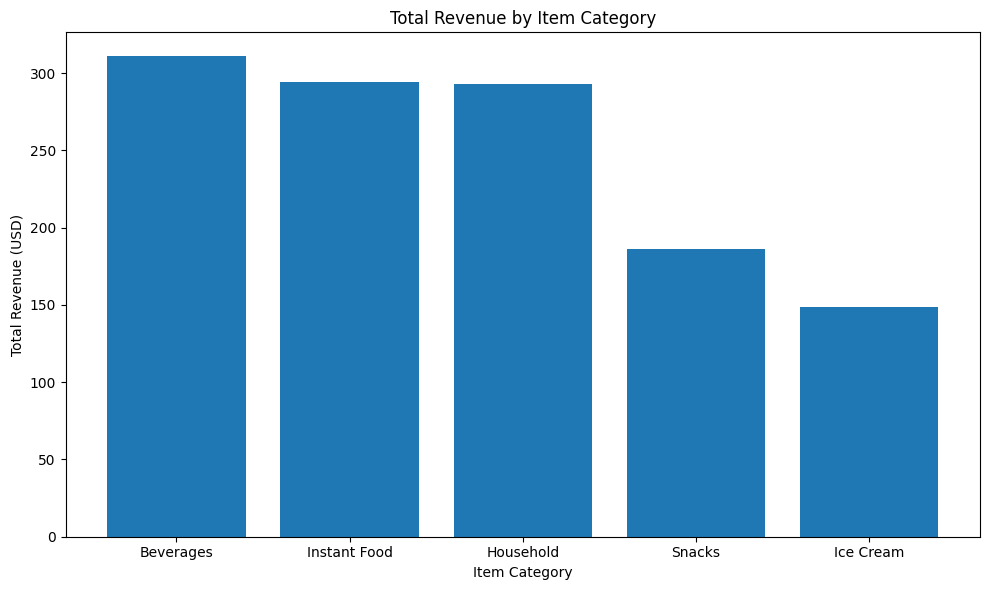

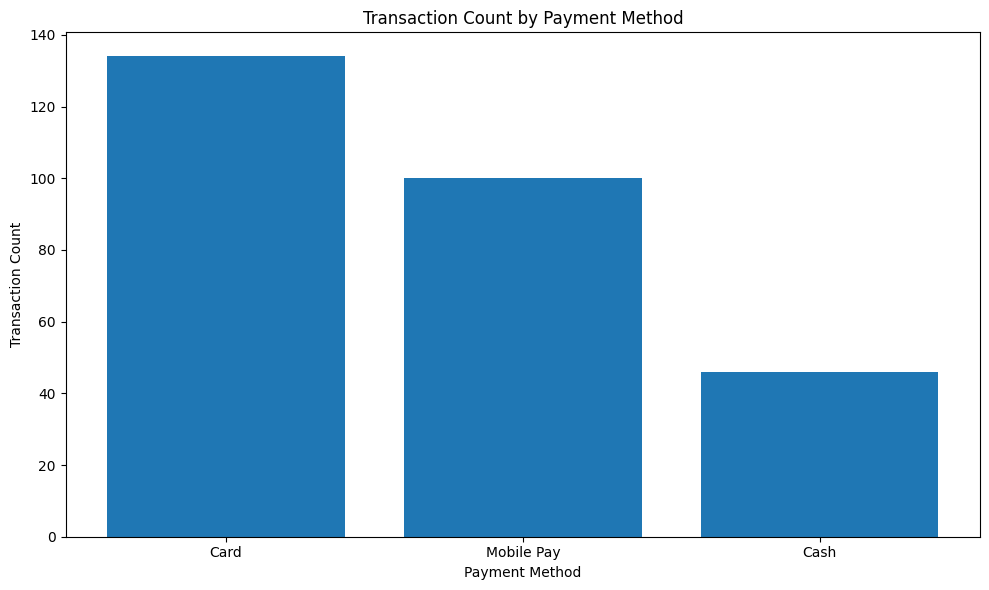

In [23]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Total revenue by item category (bar chart)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(category_revenue['item_category'], category_revenue['total_price'])
ax.set_title('Total Revenue by Item Category')
ax.set_xlabel('Item Category')
ax.set_ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

# Chart 2: Transaction count by payment method (bar chart)
payment_counts = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(payment_counts.index, payment_counts.values)
ax.set_title('Transaction Count by Payment Method')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Transaction Count')
plt.tight_layout()
plt.show()

---
# 💼 Business Insights
**What did I discover?**

- 9 of the top 10 transactions are Household, because of its high unit price ($4.80 to $7.90).
  (상위 10건 중 9건이 Household. 단가가 높기 때문($4.80~$7.90))
- Beverages have the highest revenue (**$310.80**) because they sell the most (**87** transactions). Household has only **29** transactions but earns **$293.10**, almost the same as Instant Food (**$294.10**).
  (Beverages는 가장 많이 팔려(87건) 매출 1위($310.80). Household는 29건뿐인데도 $293.10으로 Instant Food($294.10)와 거의 비슷)
- Card is the most used payment method (**134** of 280 transactions).
  (Card가 가장 많이 쓰이는 결제수단(280건 중 134건))
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Run a card payment promotion, since Card is the most used method (**134** transactions).
   (Card가 가장 많이 쓰이니(134건) 카드 결제 프로모션)
2. Protect Household stock and display, because a small number of sales brings in a large amount of revenue.
   (판매 건수가 적어도 매출이 크므로 Household 재고와 진열 관리)
3. Keep Beverages well stocked, since they have the most transactions and the highest revenue.
   (Beverages는 거래가 가장 많고 매출도 1위라 재고를 충분히)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- Q3 uses the `total_price` column that Q2 creates, so Q3 fails if Q2 has not been run first.
  (Q3가 Q2에서 만든 total_price 컬럼을 써서, Q2를 실행하지 않으면 Q3가 에러)
- Q1 is a plain filter, and I did not see its business purpose at first.
  (Q1은 단순 필터라 처음엔 어떤 비즈니스 목적인지 보이지 않았음)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- A new column is made from existing ones with `df['total_price'] = df['price'] * df['quantity']`, then `sort_values(..., ascending=False).head(10)` gives the top 10.
  (기존 컬럼끼리 곱해 새 컬럼을 만들고, sort_values와 head(10)으로 상위 10개)
- Revenue is count × unit price. A category with few sales can still earn a lot if its unit price is high (Household).
  (매출은 건수 × 단가. 판매 건수가 적어도 단가가 높으면 매출이 큼(Household))
- `groupby().agg({...})` can sum one column and count another in one step. `value_counts()` counts each value of a column.
  (agg로 한 번에 합계와 건수를 계산. value_counts는 값별 개수)
  

---
# 🧠 Reflection

**What was difficult?**
Nothing was really hard. The hardest part was explaining why Household earns so much with so few sales.
(특별히 어려운 건 없었음. Household가 적게 팔리는데도 매출이 큰 이유를 설명하는 것이 가장 난이도가 있었음)

**Why?**
The transaction count and the revenue point in different directions, so one number alone does not tell the story.
(건수와 매출이 서로 다른 방향이라 한 숫자만으로는 설명이 안 됨)

**How did I solve it?**
Looked at the count and the revenue together in the Q3 table.
(Q3 표에서 건수와 매출을 함께 봄)

**What would I do differently next time?**
Check the data once more before filling in results, so the numbers match the current data.
(결과를 적기 전에 데이터를 한 번 더 확인해 숫자가 현재 데이터와 맞는지 확인)



---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★★☆☆
(pandas 기본 작업은 이해)

**Confidence**
★★★★★★★☆☆☆

**Difficulty**
★★★☆☆☆☆☆☆☆
(복습이라 비교적 쉬웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 16 — NumPy basics (Round 2/5)
  (NumPy 기초 복습)
  